In [9]:
import seaborn as sns
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [61]:
from matplotlib import rcParams
rcParams['font.family'] = 'Gulim'
rcParams['axes.unicode_minus'] = False

In [2]:
df_abnb = pd.read_csv('./data/ABNB_stock.csv')
df_abnb.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800
1,2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100
2,2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400


In [3]:
df_abnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       454 non-null    object 
 1   Open       454 non-null    float64
 2   High       454 non-null    float64
 3   Low        454 non-null    float64
 4   Close      454 non-null    float64
 5   Adj Close  454 non-null    float64
 6   Volume     454 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 25.0+ KB


<Axes: xlabel='Date', ylabel='Close'>

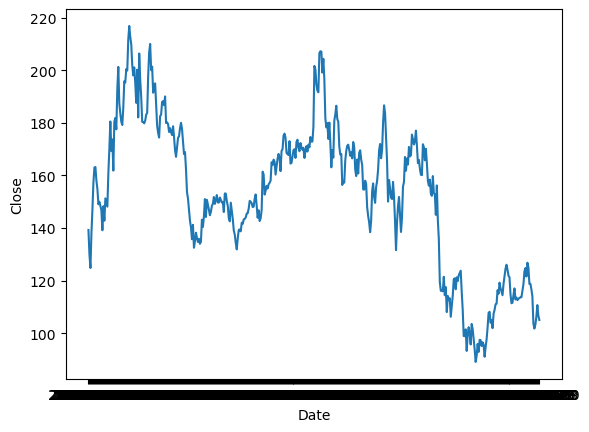

In [6]:
# seaborn
fig, ax = plt.subplots()
sns.lineplot(x='Date', y='Close', data=df_abnb)

# datetime type 으로 변환

<Axes: xlabel='Date', ylabel='Close'>

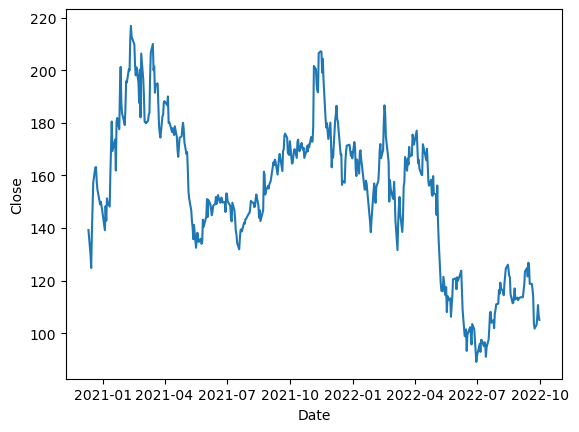

In [ ]:
df_abnb['Date'] = pd.to_datetime(df_abnb['Date'])
fig, ax = plt.subplots()
sns.lineplot(x='Date', y='Close', data=df_abnb)

# 축레벨 회전, 표현방식을 변경 > fomatter를 사용

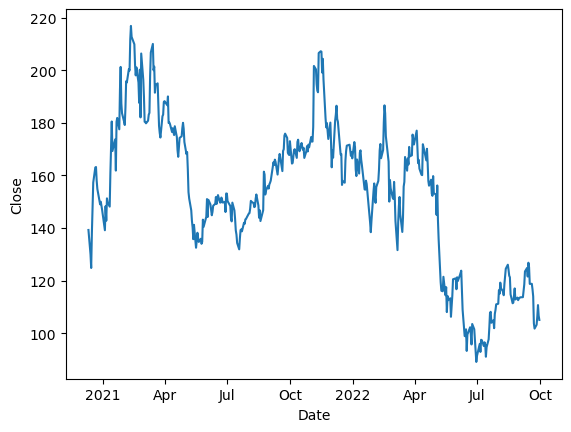

In [ ]:
import matplotlib as mpl
fig, ax = plt.subplots()
sns.lineplot(x='Date', y='Close', data=df_abnb, ax=ax)
ax.xaxis.set_major_formatter(mpl.dates.ConciseDateFormatter(ax.xaxis.get_major_formatter()))

## plotly line

In [ ]:
px.line(df_abnb, x='Date', y='Close',width=500, height=400 )

In [11]:
fig = px.line(df_abnb, x='Date', y='Close',width=500, height=400 )
fig.update_xaxes(tickformat='%Y-%m-%d')

# 다중축 차트
- 기본차트 x,y + y1,y2 -> 하나의 ax에 그리기

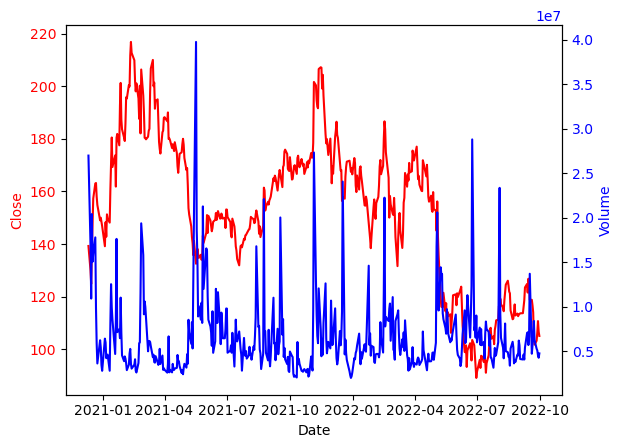

In [19]:
fig,ax = plt.subplots()
ax2=ax.twinx()

sns.lineplot( df_abnb,x='Date', y='Close', ax=ax, color='red')
sns.lineplot( df_abnb,x='Date', y='Volume',  ax=ax2, color='blue')

# 왼쪽 y축에 정보 설정
ax.tick_params(axis='y', labelcolor='red')
ax.yaxis.label.set_color('red')
# 오른쪽 y축에 정보 설정
ax2.tick_params(axis='y', labelcolor='blue')
ax2.yaxis.label.set_color('blue')

# x축 날짜 포맷 지정하기


## 3개 축

In [ ]:
# 최고가 - 최저가 - High_low 변수 추가
df_abnb['High-Low']=df_abnb['High']-df_abnb['Low']
df_abnb.head(1)

,Date,Open,High,Low,Close,Adj Close,Volume,High-Low
0,2020-12-11,146.550003,151.5,135.100006,139.25,139.25,26980800,16.399994


<Axes: xlabel='Date', ylabel='High-Low'>

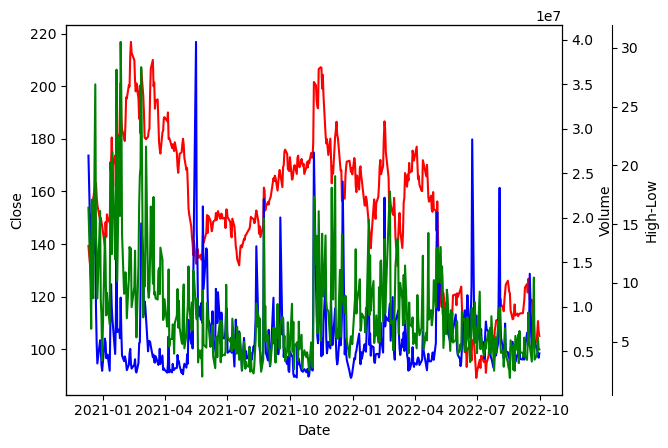

In [23]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax3 = ax.twinx()

ax3.spines.right.set_position(('axes', 1.1)) # 1.2만큼 오른쪽으로 이동

sns.lineplot( df_abnb,x='Date', y='Close', ax=ax, color='red')
sns.lineplot( df_abnb,x='Date', y='Volume',  ax=ax2, color='blue')
sns.lineplot( df_abnb,x='Date', y='High-Low',  ax=ax3, color='green')

## plotly 로 2중축 차트

In [ ]:
from plotly.subplots import make_subplots
fig = make_subplots(specs=[[{"secondary_y": True}]]) # 2차원 리스트로 spec지정

# 축 설정
sub_fig1 = px.line(df_abnb, x='Date', y='Close')
sub_fig1.update_traces(line_color='red')
sub_fig2 = px.line(df_abnb, x='Date', y='Volume')
sub_fig2.update_traces(line_color='blue')

sub_fig2.update_traces(yaxis='y2')
fig.add_traces(sub_fig1.data + sub_fig2.data)

# 레이블 설정
fig.layout.xaxis.title = 'Date'
fig.layout.yaxis.title = 'Close'
fig.layout.yaxis.color = 'red'
fig.layout.yaxis2.title = 'Volume'
fig.layout.yaxis2.color = 'blue'

fig.update_layout(width=500, height= 400)


## graph_object 3개 축 그리기

In [ ]:
import plotly.graph_objects as go

fig = make_subplots()
fig.add_trace(
  go.Scatter(
    x=df_abnb['Date'], y=df_abnb['Close'], name='Close',
    mode='lines', yaxis='y', line={'color':'red'}
    ) #1번째 축
)
fig.add_trace(
  go.Scatter(
    x=df_abnb['Date'], y=df_abnb['Volume'], name='Volume',
    mode='lines', yaxis='y2', line={'color':'blue'}
    ) #2번째 축 Volume
)
fig.add_trace(
  go.Scatter(
    x=df_abnb['Date'], y=df_abnb['High-Low'], name='High-Low',
    mode='lines', yaxis='y3', line={'color':'green'}
    ) #3번째 축 High-Low
)
fig.update_layout(
  yaxis = dict(title='Close'),
  yaxis2 = dict(title='Volume', position=1, side='right', overlaying='y', anchor='free'),
  yaxis3 = dict(title='High-Low', side='right', anchor='x', overlaying='y'),
  xaxis = dict(title='Date', domain=[.1, .85]),
  width=600, height=400
)
fig.layout.yaxis.color = 'red'
fig.layout.yaxis2.color = 'blue'
fig.layout.yaxis3.color = 'green'

fig.show()

In [35]:
df_co2 = pd.read_csv('./data/CO2_Emissions.csv')
df_co2.head(3)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136


# 범례 위치 조정하기

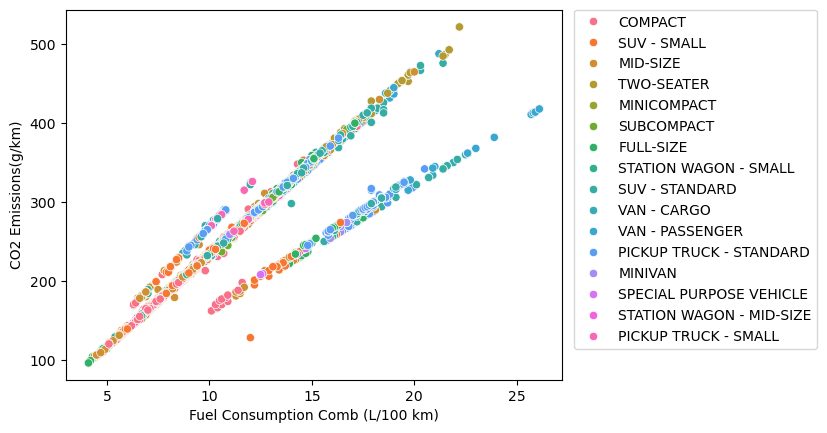

In [ ]:
fig,ax = plt.subplots()
sns.scatterplot(
    df_co2,
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    hue='Vehicle Class',
    ax=ax
)
ax.legend(bbox_to_anchor=(1.01, 1.02)) # 왼쪽 하단 0.0, 오른쪽 상단 1.1


## plotly scatter

In [ ]:
fig = px.scatter(df_co2,
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    color='Vehicle Class',
    )
fig.update_layout(legend_x=1.02, legend_y=1)
fig.show()

# 강조하기

## 테두리 색, 굵기 조정

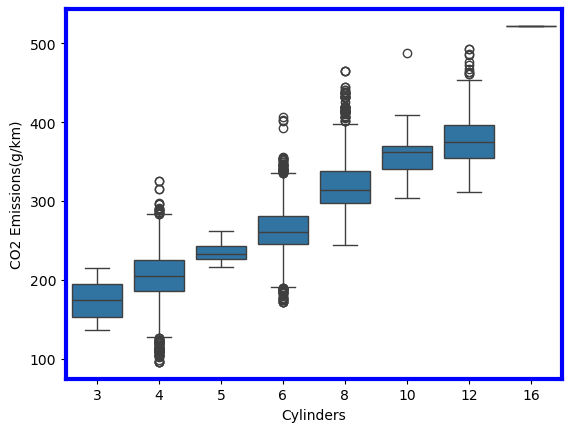

In [55]:
fig,ax = plt.subplots()
sns.boxplot(
    df_co2,
    x='Cylinders',
    y='CO2 Emissions(g/km)',
    ax=ax
)
spines = ['left', 'right', 'top', 'bottom']
for spin in spines:
    ax.spines[spin].set_color('blue')
    ax.spines[spin].set_linewidth(3)

In [57]:
fig = px.box(
    df_co2,
    x='Cylinders',
    y='CO2 Emissions(g/km)'
)
fig.update_xaxes(showline=True , linecolor='black', linewidth=5, mirror=True )
fig.update_yaxes(showline=True , linecolor='black', linewidth=5, mirror=True)
fig.show()

## 텍스트, annotate 로 표시하기

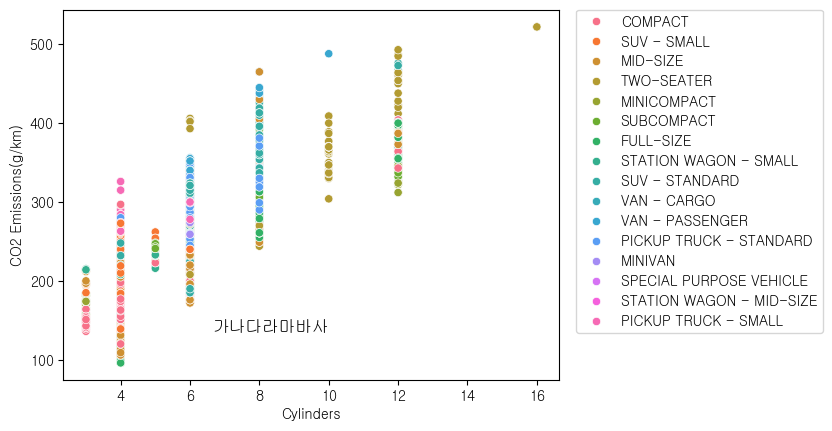

In [ ]:
# 상대 좌표
fig,ax = plt.subplots()
sns.scatterplot(
    df_co2,
    x='Cylinders',
    y='CO2 Emissions(g/km)',
    ax=ax, hue='Vehicle Class'
)
ax.text(
    x=0.3, y=0.13, # 상대좌표
    s= '가나다라마바사',
    fontdict={'fontsize':12, 'weight':'bold'}
    ,transform=ax.transAxes # 상대좌표를 전달
)
ax.legend(bbox_to_anchor=(1.02,1.02))

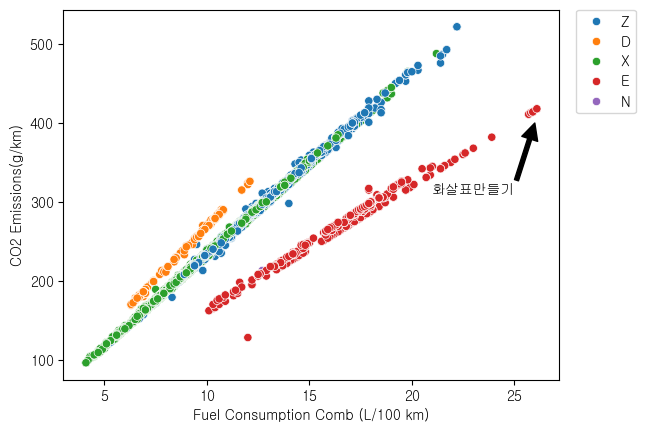

In [ ]:
# 절대좌표
fig,ax = plt.subplots()
sns.scatterplot(
    df_co2,
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    ax=ax, hue='Fuel Type'
)
ax.annotate(
    xy=(26,400), # 절대좌표
    text = '화살표만들기',
    xytext = (21,310), arrowprops = {'color':'black', 'width':3}
)
ax.legend(bbox_to_anchor=(1.02,1.02))

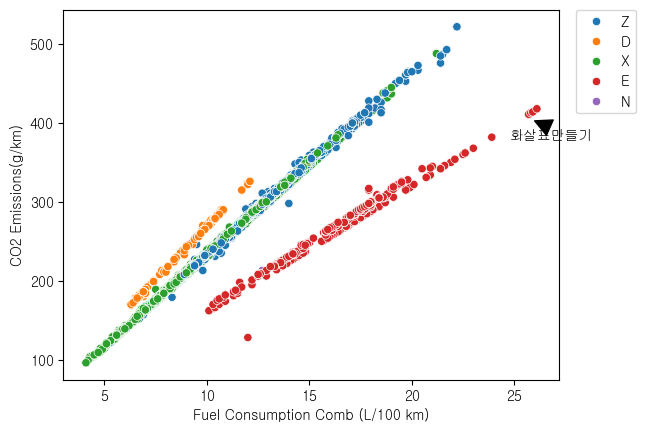

In [72]:
# annotate로 표시하기
# 텍스트, annotate 로 표시하기
fig,ax = plt.subplots()
sns.scatterplot(
    df_co2,
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    ax=ax, hue='Fuel Type'
)
ax.annotate(
    xy=(0.95, 0.7), # 상대좌표
    xycoords=ax.transAxes,
    text = '화살표만들기',
    xytext = (0.9,0.65), arrowprops = {'color':'black', 'width':3}
)
ax.legend(bbox_to_anchor=(1.02,1.02))

### plotly에서 화살표 만들기

In [ ]:
fig = px.scatter(df_co2,
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    color='Vehicle Class',
    )
fig.update_layout(legend_x=1.02, legend_y=1)

fig.add_annotation(
    # x=20, y=130,
    x=0.9, y=0.75,
    yref='y domain', xref='x domain',
    text='<b> 안녕하세요 </b>',
    showarrow=True, arrowhead=2, arrowcolor='green'
)
fig.show()

# 조건을 이용한 강조하기

In [81]:
df_ins = pd.read_csv('./data/product_inspection.csv')
df_ins.head(3)

,date,inspection_step,value,upper_spec,target,lower_spec
0,2022-01-01,A,21.2,22.0,21.3,20.6
1,2022-01-02,A,21.7,22.0,21.3,20.6
2,2022-01-03,A,21.4,22.0,21.3,20.6


In [82]:
df_ins['date'] = pd.to_datetime(df_ins['date'])

In [84]:
df_ins_A = df_ins.query("inspection_step=='A'")
df_ins_A.head(3)

,date,inspection_step,value,upper_spec,target,lower_spec
0,2022-01-01,A,21.2,22.0,21.3,20.6
1,2022-01-02,A,21.7,22.0,21.3,20.6
2,2022-01-03,A,21.4,22.0,21.3,20.6


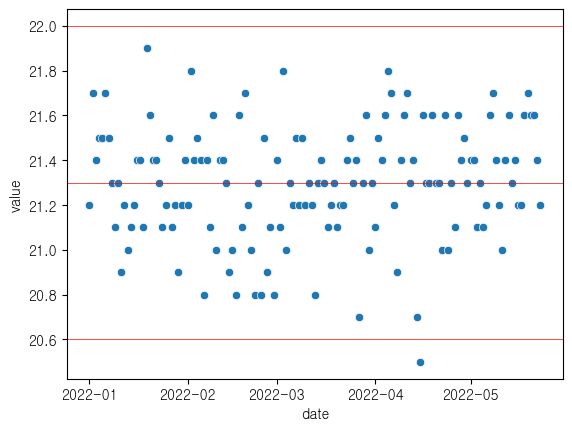

In [87]:
fig, ax = plt.subplots()
sns.scatterplot(df_ins_A, x='date', y = 'value', ax=ax)
# 수평선 그리기
ax.axhline(df_ins_A['lower_spec'].iloc[-1], color='red', linewidth=0.5)
ax.axhline(df_ins_A['target'].iloc[-1], color='red', linewidth=0.5)
ax.axhline(df_ins_A['upper_spec'].iloc[-1], color='red', linewidth=0.5)


In [92]:
# plotly
fig = px.scatter(df_ins_A, x='date', y='value',width=500, height=400)
fig.add_hline(df_ins_A['lower_spec'].iloc[-1])
fig.add_hline(df_ins_A['target'].iloc[-1])
fig.add_hline(df_ins_A['upper_spec'].iloc[-1])

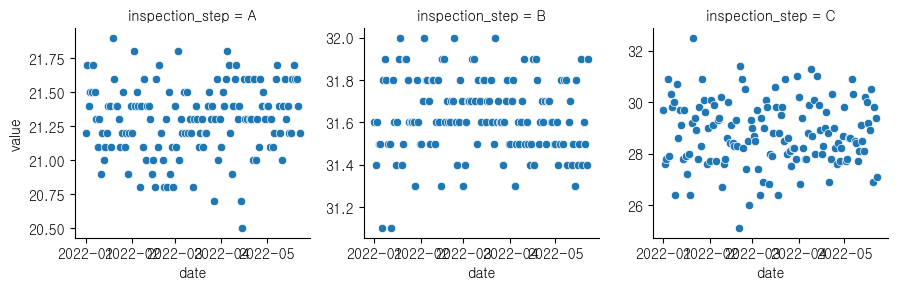

In [94]:
# FacetGrid 
import matplotlib.pyplot as plt
g = sns.FacetGrid(df_ins, sharex=False, sharey=False, col='inspection_step')
g.map_dataframe(sns.scatterplot, x='date', y='value')

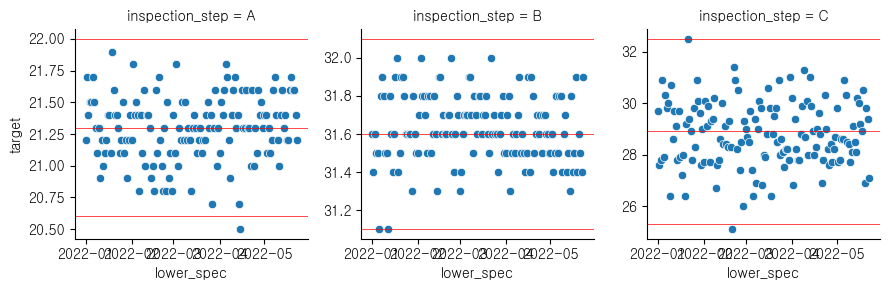

In [96]:
def custom(lower_spec, target, upper_spec, **kws):
    ax=plt.gca()
    ax.axhline(lower_spec.iloc[-1], color='red', linewidth=0.5)
    ax.axhline(target.iloc[-1], color='red', linewidth=0.5)
    ax.axhline(upper_spec.iloc[-1], color='red', linewidth=0.5)
    
g = sns.FacetGrid(df_ins, sharex=False, sharey=False, col='inspection_step')
g.map_dataframe(sns.scatterplot, x='date', y='value')
g.map(custom, 'lower_spec', 'target', 'upper_spec')

In [99]:
# Plotly에서의 활용
df = pd.read_csv('./data/product_inspection.csv')
df['date'] = pd.to_datetime(df['date'])

fig = px.scatter(df, x='date', y='value', facet_col='inspection_step')
print(fig.layout.annotations)

# For 문을 이용한 plotly에서의 facet mapping
fig = px.scatter(df, x='date', y='value', facet_col='inspection_step', facet_col_spacing=0.05)

for idx in range(df['inspection_step'].nunique()):
    step = fig.layout.annotations[idx].text.split('=')[1]
    fig.add_hline(
        y=df.query('inspection_step == @step')['lower_spec'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )
    fig.add_hline(
        y=df.query('inspection_step == @step')['upper_spec'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )
    fig.add_hline(
        y=df.query('inspection_step == @step')['target'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )

fig.update_yaxes(matches=None)
fig.update_yaxes(showticklabels=True)
fig.show()

(layout.Annotation({
    'font': {},
    'showarrow': False,
    'text': 'inspection_step=A',
    'x': 0.15999999999999998,
    'xanchor': 'center',
    'xref': 'paper',
    'y': 1.0,
    'yanchor': 'bottom',
    'yref': 'paper'
}), layout.Annotation({
    'font': {},
    'showarrow': False,
    'text': 'inspection_step=B',
    'x': 0.49999999999999994,
    'xanchor': 'center',
    'xref': 'paper',
    'y': 1.0,
    'yanchor': 'bottom',
    'yref': 'paper'
}), layout.Annotation({
    'font': {},
    'showarrow': False,
    'text': 'inspection_step=C',
    'x': 0.8399999999999999,
    'xanchor': 'center',
    'xref': 'paper',
    'y': 1.0,
    'yanchor': 'bottom',
    'yref': 'paper'
}))


In [100]:
# 특정조건에 해당하는 값 찾기
# 공정별로 관리스펙에서 벗어난 자재가 있는 그래프 테두리 강조
df_ins['spec_out'] = (df_ins['value'] > df_ins['upper_spec']) |  (df_ins['value'] < df_ins['lower_spec'])
df_ins['spec_out']

0      False
1      False
2      False
3      False
4      False
       ...  
424    False
425    False
426    False
427    False
428    False
Name: spec_out, Length: 429, dtype: bool

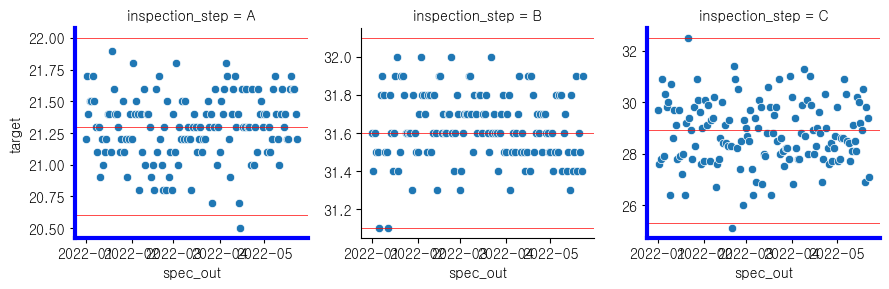

In [104]:
# facetgrid.map() 함수를 위한 커스텀 함수 정의
def custom(lower_spec, target, upper_spec, **kws):
  ax = plt.gca()
  # 수평선 그리기
  ax.axhline(lower_spec.iloc[-1], color='red', linewidth=0.5)
  ax.axhline(target.iloc[-1], color='red', linewidth=0.5)
  ax.axhline(upper_spec.iloc[-1], color='red', linewidth=0.5)

def if_spec_out(spec_out, **kws):
  if spec_out.sum() > 0:
    ax=plt.gca()
    spines = ['left', 'bottom']
    for spine in spines:
      ax.spines[spine].set_color('blue')
      ax.spines[spine].set_linewidth(3)

g = sns.FacetGrid(df_ins, sharex=False, sharey=False, col='inspection_step') #검사공정 값 A,B,C 각각 차트 구분
g.map_dataframe(sns.scatterplot, x='date', y='value')
g.map(custom, 'lower_spec', 'target', 'upper_spec')
g.map(if_spec_out, 'spec_out')

In [ ]:
# annotate 사용하기

In [ ]:
# plotly로 spec_out 강조하기

In [4]:
# 기하급수적으로 증가하는 y축 값을 변환하여 표현

In [ ]:
# 색상 선택하기